<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/Aula_3_MBA_CNN_Introducao_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Redes Neurais Convolucionais (CNN) — Introdução

## FIAP — MBA em Data Science

---

### Objetivo da Aula

Nesta aula, vamos entender **na prática** como uma Rede Neural Convolucional (CNN) funciona, passando por cada uma das suas etapas fundamentais:

1. **Representação de Imagens** — como o computador "enxerga" uma imagem
2. **Operação de Convolução** — extração de características com filtros
3. **Max Pooling** — redução de dimensionalidade mantendo informações importantes
4. **Flattening** — transformação da matriz em vetor para alimentar a rede densa
5. **Rede Neural Densa** — classificação final

Utilizaremos o dataset **Fashion MNIST** (imagens em escala de cinza 28×28) como caso prático.

---

## 📦 Instalação e Imports

Vamos começar importando as bibliotecas necessárias.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.19.0
NumPy version: 2.0.2


---

## 1️⃣ Representação de Imagens

### O que é uma imagem para o computador?

Uma imagem **não é** o que nós vemos — para o computador, é apenas uma **matriz de números**.

- **Imagem em escala de cinza**: matriz 2D onde cada valor (pixel) varia de **0 (preto)** a **255 (branco)**
- **Imagem colorida (RGB)**: 3 matrizes empilhadas (canais Red, Green, Blue) → tensor 3D

No Fashion MNIST, cada imagem é **28 × 28 pixels** em escala de cinza, ou seja, uma matriz de 784 valores.

Vamos carregar o dataset e visualizar como o computador "enxerga" uma imagem.

In [2]:
# Carregando o Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nomes das classes
class_names = [
    '0 - T-shirt/top', '1 - Trouser', '2 - Pullover', '3 - Dress', '4 - Coat',
    '5 - Sandal', '6 - Shirt', '7 - Sneaker', '8 - Bag', '9 - Ankle boot'
]

print(f"Formato dos dados de treino: {X_train.shape}")
print(f"Formato dos dados de teste:  {X_test.shape}")
print(f"Quantidade de classes: {len(class_names)}")
print(f"Valores dos pixels variam de {X_train.min()} a {X_train.max()}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato dos dados de treino: (60000, 28, 28)
Formato dos dados de teste:  (10000, 28, 28)
Quantidade de classes: 10
Valores dos pixels variam de 0 a 255


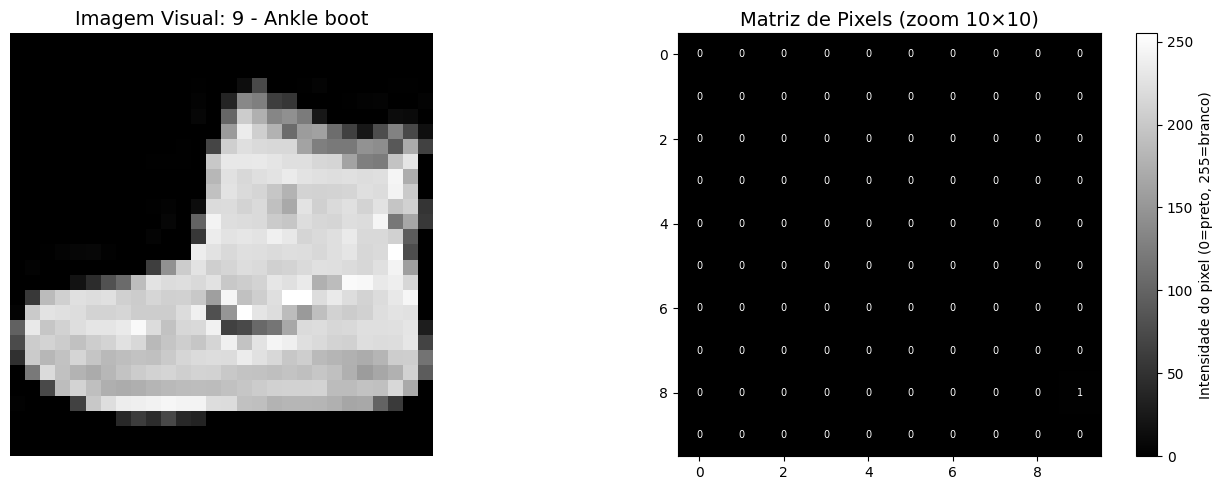


Shape da imagem: (28, 28)
Total de pixels: 784 = 28×28


In [3]:
# Visualizando uma imagem e sua matriz de pixels
idx = 0  # índice da imagem que vamos explorar
imagem = X_train[idx]
label = y_train[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lado esquerdo: imagem visual
axes[0].imshow(imagem, cmap='gray')
axes[0].set_title(f"Imagem Visual: {class_names[label]}", fontsize=14)
axes[0].axis('off')

# Lado direito: matriz numérica (zoom nos primeiros 10x10 pixels)
zoom = imagem[:10, :10]
im = axes[1].imshow(zoom, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Matriz de Pixels (zoom 10×10)", fontsize=14)

# Adicionando os valores numéricos em cada célula
for i in range(10):
    for j in range(10):
        cor_texto = 'white' if zoom[i, j] < 128 else 'black'
        axes[1].text(j, i, str(zoom[i, j]), ha='center', va='center', fontsize=7, color=cor_texto)

plt.colorbar(im, ax=axes[1], label='Intensidade do pixel (0=preto, 255=branco)')
plt.tight_layout()
plt.show()

print(f"\nShape da imagem: {imagem.shape}")
print(f"Total de pixels: {imagem.shape[0] * imagem.shape[1]} = {imagem.shape[0]}×{imagem.shape[1]}")

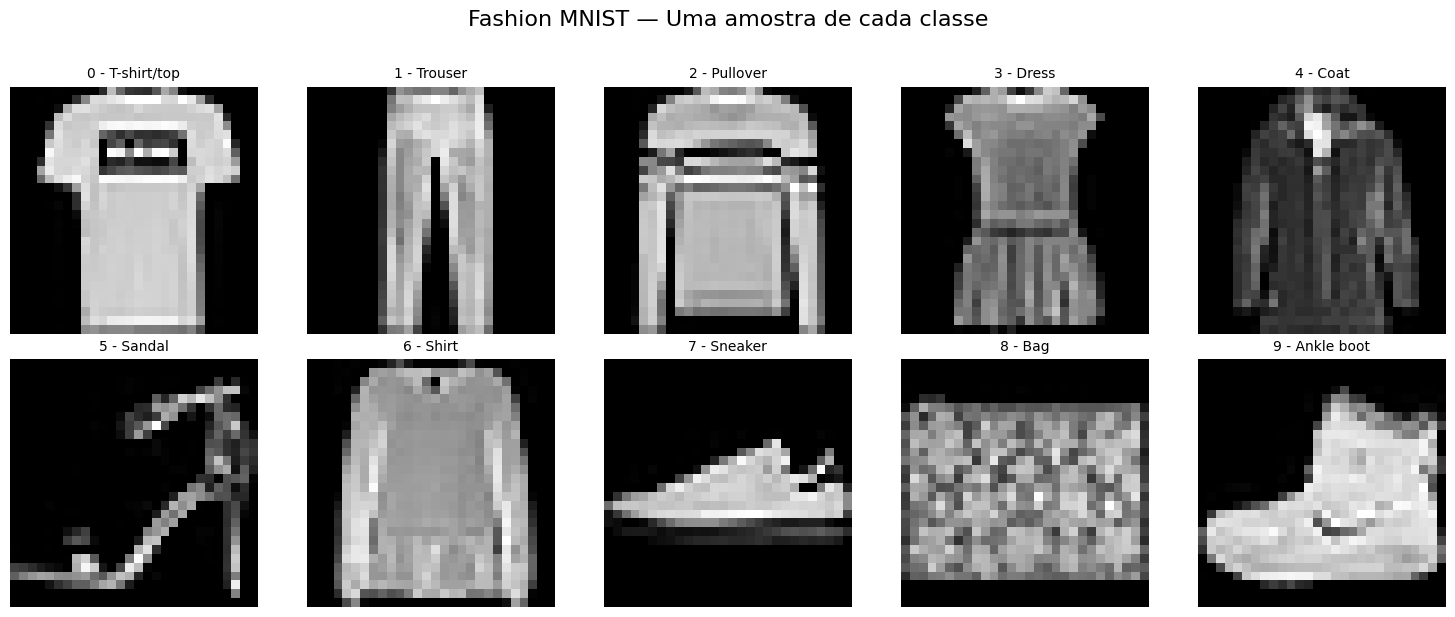

In [4]:
# Visualizando 10 exemplos — um de cada classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Encontra o primeiro exemplo de cada classe
    idx_classe = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx_classe], cmap='gray')
    axes[i].set_title(class_names[i], fontsize=10)
    axes[i].axis('off')

plt.suptitle('Fashion MNIST — Uma amostra de cada classe', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 💡 Pergunta para reflexão

> Se cada imagem tem 28×28 = **784 pixels**, poderíamos usar esses 784 valores como features em uma rede neural densa tradicional?
>
> **Sim**, mas perderíamos a **informação espacial** — a relação entre pixels vizinhos. É exatamente isso que a CNN resolve!

---

## 2️⃣ Etapa 1 — Operação de Convolução

### O que é convolução?

A **convolução** é uma operação matemática que aplica um **filtro** (também chamado de **kernel**) sobre a imagem, deslizando-o pixel a pixel. Em cada posição, o filtro multiplica seus valores pelos pixels correspondentes da imagem e soma tudo, produzindo um único valor no **mapa de características** (feature map).

### Por que fazer isso?

Os filtros detectam **padrões visuais** específicos:
- Bordas verticais
- Bordas horizontais
- Cantos
- Texturas

### Fórmula simplificada

Para um filtro 2×2 aplicado numa região 2×2 da imagem:

$$\text{resultado} = \sum_{i} \sum_{j} \text{imagem}[i,j] \times \text{filtro}[i,j]$$

Vamos ver isso na prática com um exemplo simples!

In [5]:
# ============================================================
# EXEMPLO DIDÁTICO — Convolução passo a passo
# ============================================================

# Imagem simples 5×5 (igual ao slide da aula)
imagem_simples = np.array([
    [1, 1, 1, 0, 0],
    [1, 1, 0, 0, 1],
    [0, 1, 1, 0, 1],
    [0, 0, 0, 0, 0]
])

# Filtro (kernel) 2×2
filtro = np.array([
    [1, 1],
    [1, 0]
])

print("Imagem de entrada (4×5):")
print(imagem_simples)
print("\nFiltro (kernel) 2×2:")
print(filtro)

Imagem de entrada (4×5):
[[1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 1 0 1]
 [0 0 0 0 0]]

Filtro (kernel) 2×2:
[[1 1]
 [1 0]]


In [6]:
# Convolução manual — passo a passo
img_h, img_w = imagem_simples.shape
f_h, f_w = filtro.shape

# Dimensões do mapa de características resultante
out_h = img_h - f_h + 1  # 4 - 2 + 1 = 3
out_w = img_w - f_w + 1  # 5 - 2 + 1 = 4

mapa_caracteristicas = np.zeros((out_h, out_w), dtype=int)

print(f"Imagem: {img_h}×{img_w}")
print(f"Filtro: {f_h}×{f_w}")
print(f"Mapa de características resultante: {out_h}×{out_w}")
print("\n" + "="*60)
print("PASSO A PASSO DA CONVOLUÇÃO:")
print("="*60)

for i in range(out_h):
    for j in range(out_w):
        # Extrai a região da imagem (campo receptivo)
        regiao = imagem_simples[i:i+f_h, j:j+f_w]

        # Multiplicação elemento a elemento + soma
        produto = regiao * filtro
        resultado = produto.sum()
        mapa_caracteristicas[i, j] = resultado

        print(f"\nPosição [{i},{j}]:")
        print(f"  Região da imagem: {regiao.flatten()} × Filtro: {filtro.flatten()}")
        termos = [f"{r}×{f}" for r, f in zip(regiao.flatten(), filtro.flatten())]
        print(f"  Cálculo: {' + '.join(termos)} = {resultado}")

print("\n" + "="*60)
print("\nMapa de Características Final:")
print(mapa_caracteristicas)

Imagem: 4×5
Filtro: 2×2
Mapa de características resultante: 3×4

PASSO A PASSO DA CONVOLUÇÃO:

Posição [0,0]:
  Região da imagem: [1 1 1 1] × Filtro: [1 1 1 0]
  Cálculo: 1×1 + 1×1 + 1×1 + 1×0 = 3

Posição [0,1]:
  Região da imagem: [1 1 1 0] × Filtro: [1 1 1 0]
  Cálculo: 1×1 + 1×1 + 1×1 + 0×0 = 3

Posição [0,2]:
  Região da imagem: [1 0 0 0] × Filtro: [1 1 1 0]
  Cálculo: 1×1 + 0×1 + 0×1 + 0×0 = 1

Posição [0,3]:
  Região da imagem: [0 0 0 1] × Filtro: [1 1 1 0]
  Cálculo: 0×1 + 0×1 + 0×1 + 1×0 = 0

Posição [1,0]:
  Região da imagem: [1 1 0 1] × Filtro: [1 1 1 0]
  Cálculo: 1×1 + 1×1 + 0×1 + 1×0 = 2

Posição [1,1]:
  Região da imagem: [1 0 1 1] × Filtro: [1 1 1 0]
  Cálculo: 1×1 + 0×1 + 1×1 + 1×0 = 2

Posição [1,2]:
  Região da imagem: [0 0 1 0] × Filtro: [1 1 1 0]
  Cálculo: 0×1 + 0×1 + 1×1 + 0×0 = 1

Posição [1,3]:
  Região da imagem: [0 1 0 1] × Filtro: [1 1 1 0]
  Cálculo: 0×1 + 1×1 + 0×1 + 1×0 = 1

Posição [2,0]:
  Região da imagem: [0 1 0 0] × Filtro: [1 1 1 0]
  Cálculo: 0×1 +

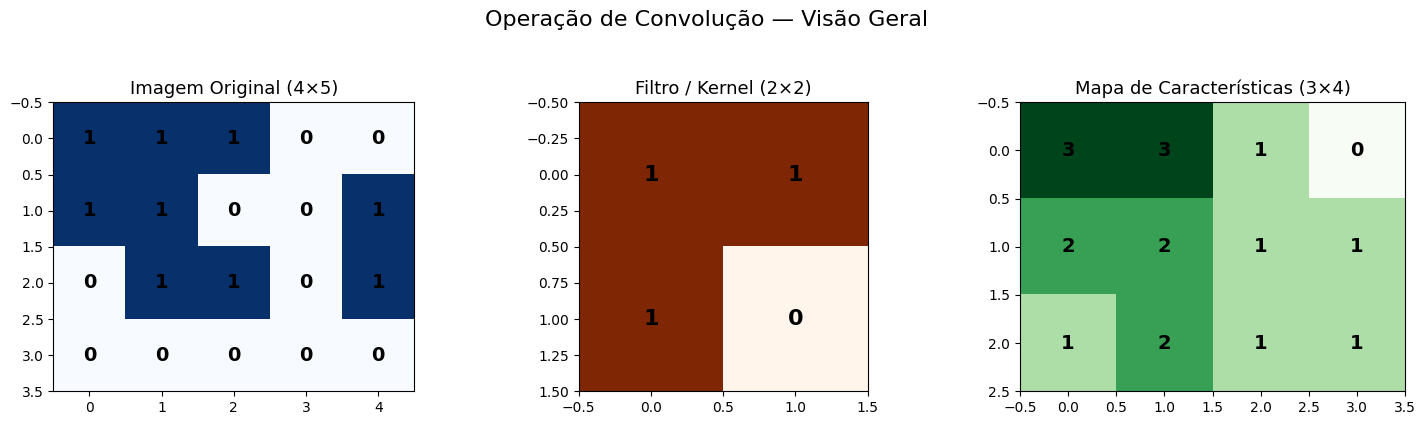

In [7]:
# Visualização gráfica da convolução
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Imagem original
im0 = axes[0].imshow(imagem_simples, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Imagem Original (4×5)', fontsize=13)
for i in range(imagem_simples.shape[0]):
    for j in range(imagem_simples.shape[1]):
        axes[0].text(j, i, str(imagem_simples[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')

# Filtro
im1 = axes[1].imshow(filtro, cmap='Oranges', vmin=0, vmax=1)
axes[1].set_title('Filtro / Kernel (2×2)', fontsize=13)
for i in range(filtro.shape[0]):
    for j in range(filtro.shape[1]):
        axes[1].text(j, i, str(filtro[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

# Mapa de características
im2 = axes[2].imshow(mapa_caracteristicas, cmap='Greens', vmin=0, vmax=3)
axes[2].set_title('Mapa de Características (3×4)', fontsize=13)
for i in range(mapa_caracteristicas.shape[0]):
    for j in range(mapa_caracteristicas.shape[1]):
        axes[2].text(j, i, str(mapa_caracteristicas[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')

plt.suptitle('Operação de Convolução — Visão Geral', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Aplicando filtros reais em uma imagem do Fashion MNIST

Agora vamos aplicar diferentes filtros em uma imagem real e ver o que cada um detecta.

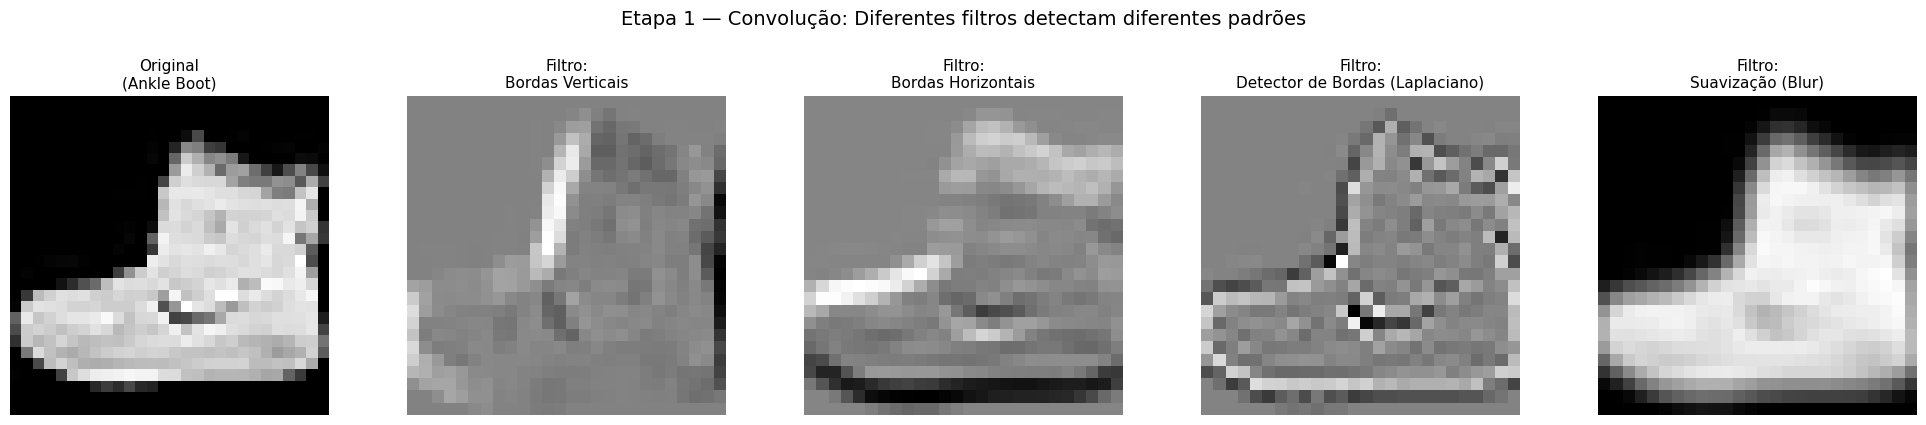

In [8]:
# Definindo filtros clássicos de detecção de bordas
filtros = {
    'Bordas Verticais': np.array([[-1, 0, 1],
                                  [-1, 0, 1],
                                  [-1, 0, 1]]),

    'Bordas Horizontais': np.array([[-1, -1, -1],
                                    [ 0,  0,  0],
                                    [ 1,  1,  1]]),

    'Detector de Bordas (Laplaciano)': np.array([[ 0, -1,  0],
                                                  [-1,  4, -1],
                                                  [ 0, -1,  0]]),

    'Suavização (Blur)': np.array([[1, 1, 1],
                                    [1, 1, 1],
                                    [1, 1, 1]]) / 9.0
}

# Pegando uma imagem de exemplo (ankle boot)
idx_boot = np.where(y_train == 9)[0][0]
img_exemplo = X_train[idx_boot].astype(float)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Imagem original
axes[0].imshow(img_exemplo, cmap='gray')
axes[0].set_title('Original\n(Ankle Boot)', fontsize=11)
axes[0].axis('off')

# Aplicando cada filtro
for ax, (nome, filtro) in zip(axes[1:], filtros.items()):
    resultado = correlate2d(img_exemplo, filtro, mode='valid')
    ax.imshow(resultado, cmap='gray')
    ax.set_title(f'Filtro:\n{nome}', fontsize=11)
    ax.axis('off')

plt.suptitle('Etapa 1 — Convolução: Diferentes filtros detectam diferentes padrões', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### 💡 Conceito-chave

> Na CNN, **os filtros não são definidos manualmente** — eles são **aprendidos automaticamente** durante o treinamento! A rede descobre sozinha quais padrões são mais relevantes para classificar as imagens.

---

## 3️⃣ Etapa 2 — Max Pooling

### O que é Max Pooling?

O **Max Pooling** é uma operação de **redução de dimensionalidade** que:

1. Divide o mapa de características em regiões (geralmente 2×2)
2. Em cada região, mantém apenas o **valor máximo**

### Por que fazer isso?

- **Reduz o tamanho** dos dados (menos parâmetros = mais rápido)
- **Torna o modelo mais robusto** a pequenas variações na posição do objeto (invariância à translação)
- Um cachorro continua sendo um cachorro, esteja ele no canto esquerdo ou no centro da foto!

Vamos ver passo a passo.

In [9]:
# ============================================================
# EXEMPLO DIDÁTICO — Max Pooling passo a passo
# ============================================================

# Usando o mapa de características que calculamos antes
print("Mapa de Características (entrada do Max Pooling):")
print(mapa_caracteristicas)
print(f"Shape: {mapa_caracteristicas.shape}")

# Vamos usar um mapa maior para o exemplo ficar mais claro
mapa_exemplo = np.array([
    [3, 3, 1, 0],
    [2, 2, 1, 1],
    [1, 2, 1, 1]
])

print("\nMapa de Características para Max Pooling (3×4):")
print(mapa_exemplo)

Mapa de Características (entrada do Max Pooling):
[[3 3 1 0]
 [2 2 1 1]
 [1 2 1 1]]
Shape: (3, 4)

Mapa de Características para Max Pooling (3×4):
[[3 3 1 0]
 [2 2 1 1]
 [1 2 1 1]]


In [10]:
# Max Pooling manual com pool_size=2×2 e stride=1
pool_h, pool_w = 2, 2
stride = 1

m_h, m_w = mapa_exemplo.shape
pool_out_h = (m_h - pool_h) // stride + 1
pool_out_w = (m_w - pool_w) // stride + 1

pooled = np.zeros((pool_out_h, pool_out_w), dtype=int)

print(f"Entrada: {m_h}×{m_w}")
print(f"Pool size: {pool_h}×{pool_w}, Stride: {stride}")
print(f"Saída: {pool_out_h}×{pool_out_w}")
print("\n" + "="*60)
print("PASSO A PASSO DO MAX POOLING:")
print("="*60)

for i in range(pool_out_h):
    for j in range(pool_out_w):
        si = i * stride
        sj = j * stride
        regiao = mapa_exemplo[si:si+pool_h, sj:sj+pool_w]
        valor_max = regiao.max()
        pooled[i, j] = valor_max

        print(f"\nPosição [{i},{j}]:")
        print(f"  Região: {regiao.flatten()} → MAX = {valor_max}")

print("\n" + "="*60)
print("\nResultado do Max Pooling:")
print(pooled)

Entrada: 3×4
Pool size: 2×2, Stride: 1
Saída: 2×3

PASSO A PASSO DO MAX POOLING:

Posição [0,0]:
  Região: [3 3 2 2] → MAX = 3

Posição [0,1]:
  Região: [3 1 2 1] → MAX = 3

Posição [0,2]:
  Região: [1 0 1 1] → MAX = 1

Posição [1,0]:
  Região: [2 2 1 2] → MAX = 2

Posição [1,1]:
  Região: [2 1 2 1] → MAX = 2

Posição [1,2]:
  Região: [1 1 1 1] → MAX = 1


Resultado do Max Pooling:
[[3 3 1]
 [2 2 1]]


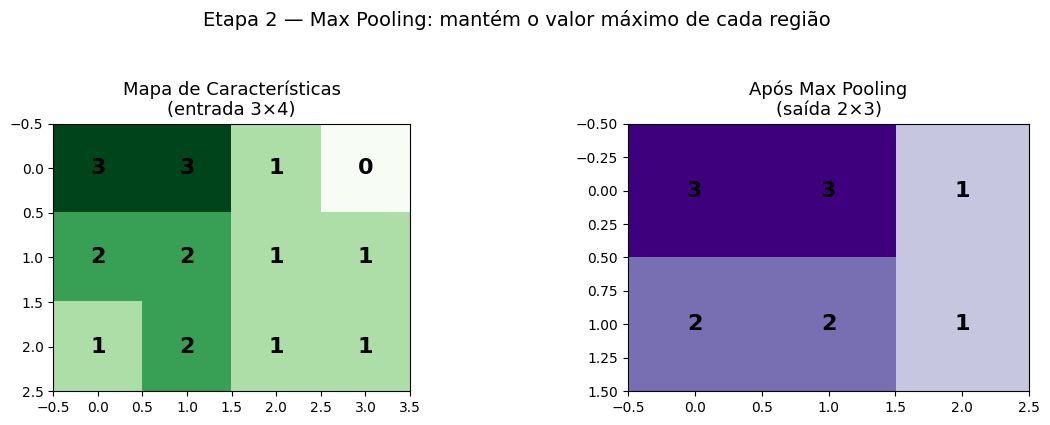

In [11]:
# Visualização gráfica do Max Pooling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Entrada
im0 = axes[0].imshow(mapa_exemplo, cmap='Greens', vmin=0, vmax=3)
axes[0].set_title(f'Mapa de Características\n(entrada {mapa_exemplo.shape[0]}×{mapa_exemplo.shape[1]})', fontsize=13)
for i in range(mapa_exemplo.shape[0]):
    for j in range(mapa_exemplo.shape[1]):
        axes[0].text(j, i, str(mapa_exemplo[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

# Saída
im1 = axes[1].imshow(pooled, cmap='Purples', vmin=0, vmax=3)
axes[1].set_title(f'Após Max Pooling\n(saída {pooled.shape[0]}×{pooled.shape[1]})', fontsize=13)
for i in range(pooled.shape[0]):
    for j in range(pooled.shape[1]):
        axes[1].text(j, i, str(pooled[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

plt.suptitle('Etapa 2 — Max Pooling: mantém o valor máximo de cada região', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

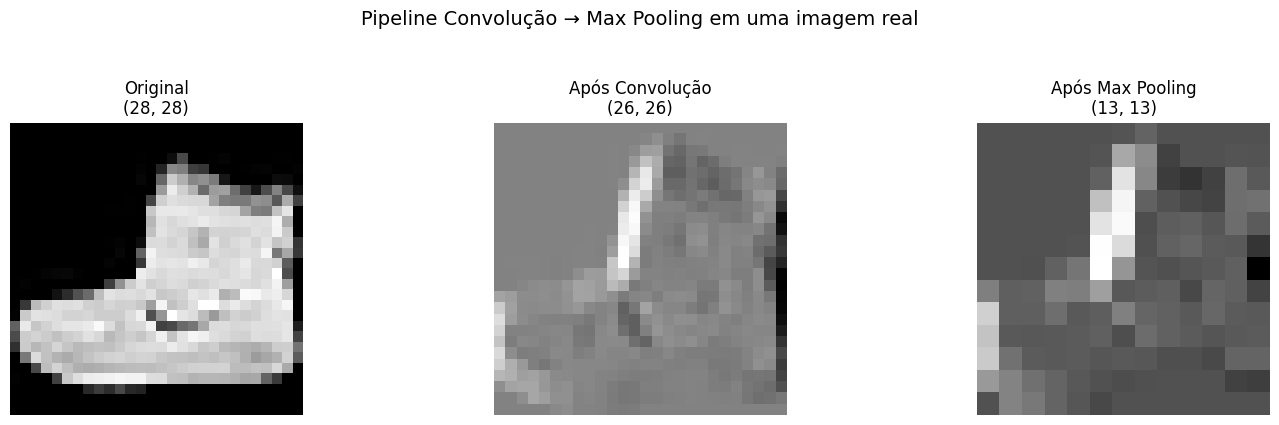

Redução de dimensionalidade:
  Original:       28×28 = 784 pixels
  Pós-Convolução: 26×26 = 676 valores
  Pós-Pooling:    13×13 = 169 valores


In [12]:
# Aplicando Max Pooling em uma imagem real do Fashion MNIST
# Primeiro aplicamos convolução, depois max pooling

img_real = X_train[idx_boot].astype(float)

# Filtro de detecção de bordas
filtro_borda = np.array([[-1, 0, 1],
                          [-1, 0, 1],
                          [-1, 0, 1]])

# Etapa 1: Convolução
convoluido = correlate2d(img_real, filtro_borda, mode='valid')

# Etapa 2: Max Pooling manual (2×2, stride 2)
pool_size = 2
c_h, c_w = convoluido.shape
p_h = c_h // pool_size
p_w = c_w // pool_size
pooled_real = np.zeros((p_h, p_w))

for i in range(p_h):
    for j in range(p_w):
        regiao = convoluido[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
        pooled_real[i, j] = regiao.max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(img_real, cmap='gray')
axes[0].set_title(f'Original\n{img_real.shape}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(convoluido, cmap='gray')
axes[1].set_title(f'Após Convolução\n{convoluido.shape}', fontsize=12)
axes[1].axis('off')

axes[2].imshow(pooled_real, cmap='gray')
axes[2].set_title(f'Após Max Pooling\n{pooled_real.shape}', fontsize=12)
axes[2].axis('off')

plt.suptitle('Pipeline Convolução → Max Pooling em uma imagem real', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print(f"Redução de dimensionalidade:")
print(f"  Original:       {img_real.shape[0]}×{img_real.shape[1]} = {img_real.shape[0]*img_real.shape[1]} pixels")
print(f"  Pós-Convolução: {convoluido.shape[0]}×{convoluido.shape[1]} = {convoluido.shape[0]*convoluido.shape[1]} valores")
print(f"  Pós-Pooling:    {pooled_real.shape[0]}×{pooled_real.shape[1]} = {int(pooled_real.shape[0]*pooled_real.shape[1])} valores")

---

## 4️⃣ Etapa 3 — Flattening

### O que é Flattening?

Após as camadas de convolução e pooling, temos uma **matriz 2D** (ou 3D, se houver múltiplos filtros). Porém, a rede neural densa que fará a classificação espera receber um **vetor 1D**.

O **Flattening** simplesmente "achata" a matriz, transformando-a em um vetor.

Exemplo: uma matriz 3×3 vira um vetor de 9 elementos.

In [13]:
# ============================================================
# EXEMPLO DIDÁTICO — Flattening passo a passo
# ============================================================

# Usando o resultado do max pooling do exemplo didático
print("Matriz após Max Pooling:")
print(pooled)
print(f"Shape: {pooled.shape}")

# Flattening
vetor_flat = pooled.flatten()
print(f"\nApós Flattening:")
print(vetor_flat)
print(f"Shape: {vetor_flat.shape}")
print(f"\nEsse vetor de {len(vetor_flat)} elementos alimentará a camada densa da rede neural!")

Matriz após Max Pooling:
[[3 3 1]
 [2 2 1]]
Shape: (2, 3)

Após Flattening:
[3 3 1 2 2 1]
Shape: (6,)

Esse vetor de 6 elementos alimentará a camada densa da rede neural!


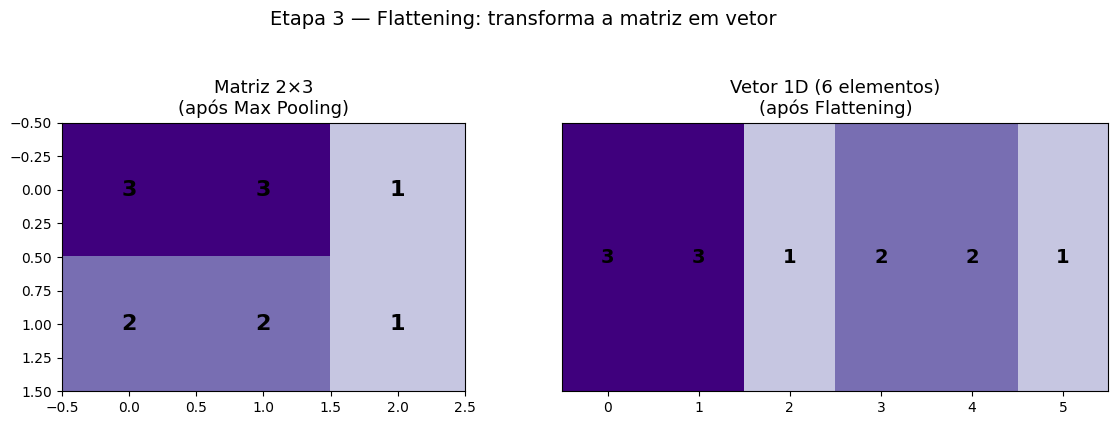

In [14]:
# Visualização gráfica do Flattening
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz (antes)
im0 = axes[0].imshow(pooled, cmap='Purples', vmin=0, vmax=3)
axes[0].set_title(f'Matriz {pooled.shape[0]}×{pooled.shape[1]}\n(após Max Pooling)', fontsize=13)
for i in range(pooled.shape[0]):
    for j in range(pooled.shape[1]):
        axes[0].text(j, i, str(pooled[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

# Vetor (depois)
vetor_2d = vetor_flat.reshape(1, -1)
im1 = axes[1].imshow(vetor_2d, cmap='Purples', vmin=0, vmax=3, aspect='auto')
axes[1].set_title(f'Vetor 1D ({len(vetor_flat)} elementos)\n(após Flattening)', fontsize=13)
axes[1].set_yticks([])
for j in range(len(vetor_flat)):
    axes[1].text(j, 0, str(vetor_flat[j]), ha='center', va='center', fontsize=14, fontweight='bold')

plt.suptitle('Etapa 3 — Flattening: transforma a matriz em vetor', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---

## 5️⃣ Etapa 4 — Rede Neural Densa (Classificação)

### O que acontece aqui?

O vetor produzido pelo Flattening alimenta uma **rede neural densa** (fully connected) que realiza a **classificação final**.

A última camada utiliza a função de ativação **Softmax**, que transforma os valores em **probabilidades** para cada classe.

### Resumo do pipeline completo

```
Imagem 28×28 → [Convolução] → [Max Pooling] → [Flattening] → [Rede Densa] → Classe predita
```

Agora vamos construir e treinar uma CNN completa!

---

## 6️⃣ Construindo a CNN Completa com TensorFlow/Keras

### Preparação dos dados

In [ ]:
# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

# 1. Normalização: pixels de [0, 255] para [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# 2. Reshape: Keras espera (amostras, altura, largura, canais)
#    Para escala de cinza, canais = 1
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

# 3. One-hot encoding dos labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Shape dos dados de treino: {X_train_cnn.shape}")
print(f"Shape dos labels de treino: {y_train_cat.shape}")
print(f"\nExemplo de label one-hot (classe {y_train[0]} = {class_names[y_train[0]]}):")
print(y_train_cat[0])

### Arquitetura da CNN

In [ ]:
# ============================================================
# CONSTRUÇÃO DO MODELO CNN
# ============================================================

modelo_cnn = Sequential([
    # --- ETAPA 1: Primeira camada de Convolução ---
    # 32 filtros de tamanho 3×3, ativação ReLU
    # input_shape = (28, 28, 1) → imagem 28×28 com 1 canal (cinza)
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),

    # --- ETAPA 2: Max Pooling ---
    # Reduz a dimensão pela metade (pool_size 2×2)
    MaxPooling2D(pool_size=(2, 2)),

    # --- Segunda camada de Convolução ---
    Conv2D(64, kernel_size=(3, 3), activation='relu'),

    # --- Segundo Max Pooling ---
    MaxPooling2D(pool_size=(2, 2)),

    # --- ETAPA 3: Flattening ---
    # Transforma a matriz 2D em vetor 1D
    Flatten(),

    # --- ETAPA 4: Rede Neural Densa ---
    Dense(128, activation='relu'),
    Dropout(0.3),  # Regularização para evitar overfitting

    # --- Camada de Saída ---
    # 10 neurônios (1 por classe) + Softmax para probabilidades
    Dense(10, activation='softmax')
])

modelo_cnn.summary()

### 💡 Entendendo o summary

Observe como a dimensão vai diminuindo a cada camada:

| Camada | Saída | O que aconteceu |
|--------|-------|----------------|
| Input | (28, 28, 1) | Imagem original |
| Conv2D (32 filtros 3×3) | (26, 26, 32) | 32 mapas de características |
| MaxPooling2D (2×2) | (13, 13, 32) | Dimensão reduzida pela metade |
| Conv2D (64 filtros 3×3) | (11, 11, 64) | 64 mapas de características mais refinados |
| MaxPooling2D (2×2) | (5, 5, 64) | Nova redução |
| Flatten | (1600) | 5×5×64 = 1600 valores em vetor |
| Dense (128) | (128) | Camada oculta |
| Dense (10) | (10) | Probabilidade de cada classe |

In [ ]:
# ============================================================
# COMPILAÇÃO E TREINAMENTO
# ============================================================

modelo_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
historico = modelo_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

In [ ]:
# ============================================================
# VISUALIZAÇÃO DO TREINAMENTO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(historico.history['accuracy'], label='Treino', linewidth=2)
axes[0].plot(historico.history['val_accuracy'], label='Validação', linewidth=2)
axes[0].set_title('Acurácia por Época', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(historico.history['loss'], label='Treino', linewidth=2)
axes[1].plot(historico.history['val_loss'], label='Validação', linewidth=2)
axes[1].set_title('Loss por Época', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# AVALIAÇÃO NO CONJUNTO DE TESTE
# ============================================================

loss_test, acc_test = modelo_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"Acurácia no conjunto de teste: {acc_test:.4f} ({acc_test*100:.2f}%)")
print(f"Loss no conjunto de teste: {loss_test:.4f}")

In [ ]:
# ============================================================
# PREDIÇÕES E VISUALIZAÇÃO
# ============================================================

# Fazendo predições
predicoes = modelo_cnn.predict(X_test_cnn[:16])

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for i in range(16):
    axes[i].imshow(X_test[i], cmap='gray')

    classe_predita = np.argmax(predicoes[i])
    confianca = predicoes[i][classe_predita] * 100
    classe_real = y_test[i]

    cor = 'green' if classe_predita == classe_real else 'red'

    axes[i].set_title(
        f"Pred: {class_names[classe_predita].split(' - ')[1]}\n"
        f"Real: {class_names[classe_real].split(' - ')[1]}\n"
        f"Confiança: {confianca:.1f}%",
        fontsize=9, color=cor
    )
    axes[i].axis('off')

plt.suptitle('Predições da CNN — Verde = Correto | Vermelho = Errado', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 7️⃣ Visualizando o que a CNN Aprende

Uma das coisas mais fascinantes das CNNs é poder visualizar **o que cada camada aprendeu**. Vamos extrair os filtros e os mapas de ativação da primeira camada convolucional.

In [ ]:
# ============================================================
# VISUALIZANDO OS FILTROS APRENDIDOS (1ª camada convolucional)
# ============================================================

# Extraindo os pesos da primeira camada Conv2D
filtros_aprendidos, biases = modelo_cnn.layers[0].get_weights()
print(f"Shape dos filtros: {filtros_aprendidos.shape}")
print(f"São {filtros_aprendidos.shape[3]} filtros de {filtros_aprendidos.shape[0]}×{filtros_aprendidos.shape[1]}")

# Plotando os primeiros 16 filtros
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(32, filtros_aprendidos.shape[3])):
    filtro_i = filtros_aprendidos[:, :, 0, i]
    axes[i].imshow(filtro_i, cmap='viridis')
    axes[i].set_title(f'Filtro {i+1}', fontsize=8)
    axes[i].axis('off')

plt.suptitle('Filtros aprendidos pela CNN (1ª camada convolucional)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VISUALIZANDO OS MAPAS DE ATIVAÇÃO
# ============================================================

# Modelo auxiliar que retorna a saída da primeira camada Conv2D
modelo_ativacao = tf.keras.Model(
    inputs=modelo_cnn.input,
    outputs=modelo_cnn.layers[0].output
)

# Pegando uma imagem de teste
img_teste = X_test_cnn[0:1]  # shape (1, 28, 28, 1)
ativacoes = modelo_ativacao.predict(img_teste, verbose=0)

print(f"Shape das ativações: {ativacoes.shape}")
print(f"São {ativacoes.shape[3]} mapas de ativação de {ativacoes.shape[1]}×{ativacoes.shape[2]}")

fig, axes = plt.subplots(4, 9, figsize=(18, 8))

# Primeira posição: imagem original
axes[0, 0].imshow(X_test[0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')
axes[0, 0].axis('off')

# Mapas de ativação dos primeiros 32 filtros
posicoes = [(i, j) for i in range(4) for j in range(9)]
idx_mapa = 0
for pos_idx, (i, j) in enumerate(posicoes):
    if i == 0 and j == 0:
        continue
    if idx_mapa >= 32:
        axes[i, j].axis('off')
        continue
    axes[i, j].imshow(ativacoes[0, :, :, idx_mapa], cmap='viridis')
    axes[i, j].set_title(f'Mapa {idx_mapa+1}', fontsize=8)
    axes[i, j].axis('off')
    idx_mapa += 1

plt.suptitle('Mapas de Ativação — o que cada filtro "vê" na imagem', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 8️⃣ Comparação: MLP vs CNN

Para demonstrar a vantagem da CNN, vamos treinar também uma rede neural densa (MLP) simples e comparar os resultados.

In [ ]:
# ============================================================
# MODELO MLP (rede densa tradicional) para comparação
# ============================================================

# Para o MLP, usamos os dados "achatados" (sem estrutura 2D)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

modelo_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

modelo_mlp.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historico_mlp = modelo_mlp.fit(
    X_train_flat, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

In [ ]:
# ============================================================
# COMPARAÇÃO DE RESULTADOS
# ============================================================

loss_mlp, acc_mlp = modelo_mlp.evaluate(X_test_flat, y_test_cat, verbose=0)
loss_cnn, acc_cnn = modelo_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

print("="*50)
print("COMPARAÇÃO DE RESULTADOS")
print("="*50)
print(f"\nMLP (rede densa):")
print(f"  Acurácia: {acc_mlp*100:.2f}%")
print(f"  Loss:     {loss_mlp:.4f}")
print(f"  Params:   {modelo_mlp.count_params():,}")
print(f"\nCNN (rede convolucional):")
print(f"  Acurácia: {acc_cnn*100:.2f}%")
print(f"  Loss:     {loss_cnn:.4f}")
print(f"  Params:   {modelo_cnn.count_params():,}")
print(f"\nMelhoria da CNN sobre MLP: +{(acc_cnn - acc_mlp)*100:.2f} pontos percentuais")

In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(historico_mlp.history['val_accuracy'], label='MLP (Validação)', linewidth=2, linestyle='--')
axes[0].plot(historico.history['val_accuracy'], label='CNN (Validação)', linewidth=2)
axes[0].set_title('Acurácia — MLP vs CNN', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(historico_mlp.history['val_loss'], label='MLP (Validação)', linewidth=2, linestyle='--')
axes[1].plot(historico.history['val_loss'], label='CNN (Validação)', linewidth=2)
axes[1].set_title('Loss — MLP vs CNN', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 📋 Resumo da Aula

### As 4 etapas fundamentais de uma CNN:

| Etapa | Operação | O que faz | Por que é importante |
|-------|----------|-----------|---------------------|
| 1 | **Convolução** | Aplica filtros para extrair características | Detecta bordas, texturas, padrões |
| 2 | **Max Pooling** | Reduz a dimensionalidade mantendo o máximo | Torna o modelo invariante à posição |
| 3 | **Flattening** | Transforma a matriz em vetor 1D | Prepara os dados para a rede densa |
| 4 | **Rede Densa** | Classifica com base nas features extraídas | Produz a predição final (Softmax) |

### Pontos-chave:

- Os **filtros são aprendidos automaticamente** durante o treinamento
- Camadas iniciais aprendem padrões simples (bordas), camadas profundas aprendem padrões complexos (partes de objetos)
- CNNs superam MLPs em tarefas de imagem porque **preservam a informação espacial**
- O Fashion MNIST é um excelente dataset para prática por ser simples (28×28, escala de cinza) mas desafiador (10 classes de roupas)

### Próximos passos:

- Data Augmentation para melhorar a generalização
- Transfer Learning com modelos pré-treinados (VGG, ResNet)
- CNN com imagens coloridas (3 canais RGB)